# Hospital Readmission Fairness Audit
## Notebook 03 - Debiasing & the Fairness-Accuracy Trade-off

This notebook covers **Section 5 (debiasing interventions)** and **Section 6 (the fairness-accuracy trade-off)**.

We focus the debiasing on **race**, and on the **equalized-odds / FNR** criterion motivated in Notebook 02.

> **How to run this notebook**
>
> Open it in **Google Colab** (or a local Jupyter install with internet access) and run the cells top to bottom (`Runtime -> Run all`).
> The first code cell installs the extra packages; the next cell downloads the dataset automatically from the UCI ML Repository.
> Run **Notebook 01 first** — it saves `diabetic_clean.csv`, which notebooks 02 and 03 reuse. (02 and 03 will rebuild it automatically if it is missing.)

## Section 5 - Debiasing Interventions

We apply one intervention at each stage of the pipeline and compare them:
- **Pre-processing - reweighting**: change the *data* the model sees by reweighting training samples so each (race, outcome) cell carries equal influence.
- **In-processing - fairness-constrained training**: change the *training objective* with Fairlearn's `ExponentiatedGradient` under an equalized-odds constraint.
- **Post-processing - threshold adjustment**: leave the model untouched and change the *operating point*, with Fairlearn's `ThresholdOptimizer` choosing a per-group threshold.

For each one we report fairness gaps and the accuracy cost - and we stay honest if an approach does not actually help.

In [13]:
!pip -q install ucimlrepo fairlearn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\yolo swaggins\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('diabetic_clean.csv')
except FileNotFoundError:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=296)
    df = pd.concat([ds.data.features, ds.data.targets], axis=1).replace('?', np.nan)
    df = df[df['readmitted'] != '>30'].copy()
    df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

print('Data loaded:', df.shape)

Data loaded: (66221, 49)


### Preprocessing
Identical to Notebook 02, so the debiasing results are directly comparable to the baseline.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df[df['gender'] != 'Unknown/Invalid'].copy()
df = df.dropna(subset=['race']).reset_index(drop=True)

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
cat_cols = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
            'admission_source_id', 'payer_code', 'max_glu_serum', 'A1Cresult',
            'metformin', 'insulin', 'change', 'diabetesMed']

X_df = df[num_cols + cat_cols].copy()
X_df[num_cols] = X_df[num_cols].fillna(X_df[num_cols].median())
for col in cat_cols:
    X_df[col] = X_df[col].fillna('None').astype(str)

X = pd.get_dummies(X_df, columns=cat_cols)
y = df['readmit_30'].values

idx = np.arange(len(df))
Xtr, Xte, ytr, yte, itr, ite = train_test_split(
    X, y, idx, test_size=0.25, random_state=42, stratify=df['race'])

race_tr = df.iloc[itr]['race'].values
race_te = df.iloc[ite]['race'].values

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)
print('Train:', Xtr_s.shape, '  Test:', Xte_s.shape)

Train: (48363, 113)   Test: (16122, 113)


### Baseline and a shared scoring helper
`report()` prints accuracy plus three fairness numbers, and the function we want to drive down: **FNR-gap**, the worst-minus-best false negative rate across racial groups.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from fairlearn.metrics import (MetricFrame, false_negative_rate,
                               equalized_odds_difference, demographic_parity_difference)

def report(name, pred):
    acc = accuracy_score(yte, pred)
    eod = equalized_odds_difference(yte, pred, sensitive_features=race_te)
    dpd = demographic_parity_difference(yte, pred, sensitive_features=race_te)
    fnr = MetricFrame(metrics=false_negative_rate, y_true=yte, y_pred=pred,
                      sensitive_features=race_te)
    print('%-26s acc=%.3f  EO-diff=%.3f  DP-diff=%.3f  FNR-gap=%.3f' % (
        name, acc, eod, dpd, fnr.difference()))
    return {'method': name, 'accuracy': acc, 'EO_diff': eod,
            'DP_diff': dpd, 'FNR_gap': fnr.difference()}

base = LogisticRegression(max_iter=2000, class_weight='balanced')
base.fit(Xtr_s, ytr)
base_pred = base.predict(Xte_s)
results = [report('Baseline LogReg', base_pred)]

Baseline LogReg            acc=0.704  EO-diff=0.298  DP-diff=0.166  FNR-gap=0.298


### 5.1 Pre-processing - reweighting
We give each (race, outcome) cell equal total weight in training. Underrepresented or disadvantaged combinations are upweighted so the model cannot improve overall accuracy simply by serving the majority group well.

In [17]:
groups = np.unique(race_tr)
w = np.ones(len(ytr))
for g in groups:
    for lab in [0, 1]:
        mask = (race_tr == g) & (ytr == lab)
        if mask.sum() > 0:
            w[mask] = len(ytr) / (len(groups) * 2 * mask.sum())

rw = LogisticRegression(max_iter=2000, class_weight='balanced')
rw.fit(Xtr_s, ytr, sample_weight=w)
results.append(report('Pre-proc: Reweighting', rw.predict(Xte_s)))

Pre-proc: Reweighting      acc=0.673  EO-diff=0.109  DP-diff=0.107  FNR-gap=0.085


### 5.2 In-processing - fairness-constrained training
`ExponentiatedGradient` retrains the logistic regression repeatedly, searching for a model that satisfies an **equalized-odds** constraint. The fairness requirement is baked directly into the optimisation rather than bolted on afterwards. (This cell trains many sub-models, so it is the slowest - expect a minute or two.)

In [18]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

eg = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    constraints=EqualizedOdds(), max_iter=25)
eg.fit(Xtr_s, ytr, sensitive_features=race_tr)
eg_pred = eg.predict(Xte_s)
results.append(report('In-proc: ExpGradient', eg_pred))

In-proc: ExpGradient       acc=0.708  EO-diff=0.141  DP-diff=0.022  FNR-gap=0.141


### 5.3 Post-processing - threshold adjustment
`ThresholdOptimizer` leaves the trained model exactly as it is and only adjusts the **decision threshold per racial group** to equalise error rates. In computational terms it is the least invasive intervention - it preserves the learned model and changes only the operating point.

**Important pitfall.** With its *default* objective (raw `accuracy_score`), on imbalanced data like ours the optimiser maximises accuracy by collapsing to a near-trivial "flag almost nobody" classifier: accuracy looks high (about 0.83, the base rate) but the false-negative rate is roughly 0.9 for *every* group - it "equalises" odds by helping no one. We therefore set `objective='balanced_accuracy_score'`, which keeps the classifier clinically useful while still equalising error rates. The collapse under the default objective is itself a worthwhile cautionary finding for the report.

Note also a distinct ethical concern, separate from the numbers: applying a *different decision threshold to a patient because of their race* is a form of explicit disparate treatment, which is contentious - and in some jurisdictions legally fraught - in a clinical setting.

In [19]:
from fairlearn.postprocessing import ThresholdOptimizer

to = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=2000, class_weight='balanced'),
    constraints='equalized_odds', objective='balanced_accuracy_score',
    predict_method='predict_proba', prefit=False)
to.fit(Xtr_s, ytr, sensitive_features=race_tr)
to_pred = to.predict(Xte_s, sensitive_features=race_te)
results.append(report('Post-proc: ThresholdOpt', to_pred))

Post-proc: ThresholdOpt    acc=0.644  EO-diff=0.272  DP-diff=0.033  FNR-gap=0.272


## Section 6 - Before / After and the Fairness-Accuracy Trade-off

### 6.1 Did debiasing improve fairness, and at what cost?

In [20]:
res_df = pd.DataFrame(results)
print(res_df.round(3))
print()
for name, pred in [('Baseline', base_pred), ('ThresholdOptimizer', to_pred)]:
    mf = MetricFrame(metrics=false_negative_rate, y_true=yte, y_pred=pred,
                     sensitive_features=race_te)
    print(name, '- FNR by race:')
    print(mf.by_group.round(3))
    print()

                    method  accuracy  EO_diff  DP_diff  FNR_gap
0          Baseline LogReg     0.704    0.298    0.166    0.298
1    Pre-proc: Reweighting     0.673    0.109    0.107    0.085
2     In-proc: ExpGradient     0.708    0.141    0.022    0.141
3  Post-proc: ThresholdOpt     0.644    0.272    0.033    0.272

Baseline - FNR by race:
sensitive_feature_0
AfricanAmerican    0.386
Asian              0.684
Caucasian          0.403
Hispanic           0.621
Other              0.643
Name: false_negative_rate, dtype: float64

ThresholdOptimizer - FNR by race:
sensitive_feature_0
AfricanAmerican    0.297
Asian              0.211
Caucasian          0.328
Hispanic           0.483
Other              0.405
Name: false_negative_rate, dtype: float64



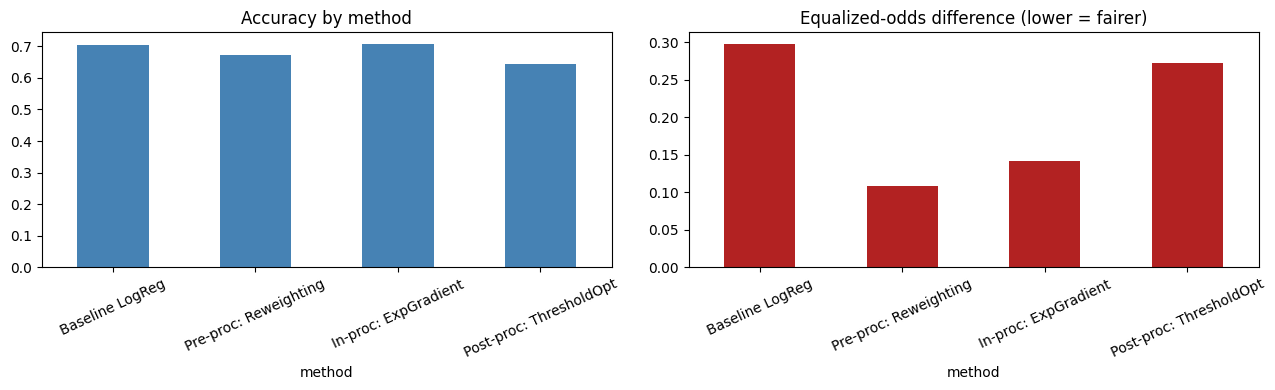

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
res_df.plot(x='method', y='accuracy', kind='bar', ax=ax[0], legend=False,
            color='steelblue', title='Accuracy by method')
res_df.plot(x='method', y='EO_diff', kind='bar', ax=ax[1], legend=False,
            color='firebrick', title='Equalized-odds difference (lower = fairer)')
for a in ax:
    a.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

**Read the table honestly.** For each method, compare `EO_diff` and `FNR_gap` against the baseline (did fairness improve?) and `accuracy` against the baseline (what did it cost?). It is a legitimate and exam-relevant result if an intervention barely moves fairness, or improves one fairness metric while leaving another untouched.

Watch out for **fake wins**: a method that posts high accuracy *and* low unfairness may simply have stopped flagging anyone (check that its per-group FNR is not uniformly near 1). A trustworthy result shows a *visible accuracy cost* in exchange for the fairness gain - reweighting is the clearest example of such an honest trade-off here.

### 6.2 The Pareto frontier
We sweep the equalized-odds constraint from strict to loose and plot accuracy against the remaining unfairness. This traces the set of best-achievable trade-offs.

    eps  accuracy  EO_diff
0  0.01     0.710    0.179
1  0.02     0.735    0.173
2  0.05     0.716    0.161
3  0.10     0.719    0.169
4  0.20     0.728    0.235


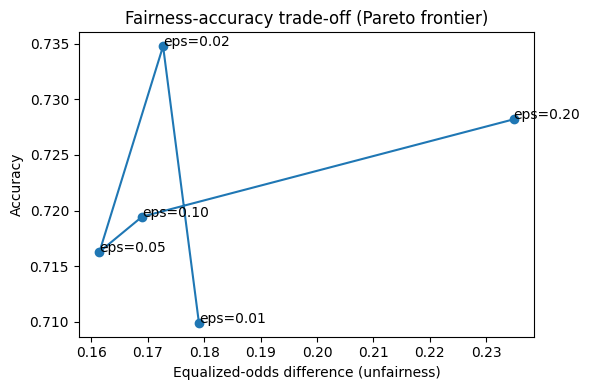

In [22]:
from sklearn.metrics import accuracy_score

pareto = []
for eps in [0.01, 0.02, 0.05, 0.1, 0.2]:
    mdl = ExponentiatedGradient(
        estimator=LogisticRegression(max_iter=800, class_weight='balanced'),
        constraints=EqualizedOdds(difference_bound=eps), max_iter=15)
    mdl.fit(Xtr_s, ytr, sensitive_features=race_tr)
    p = mdl.predict(Xte_s)
    pareto.append({'eps': eps, 'accuracy': accuracy_score(yte, p),
                   'EO_diff': equalized_odds_difference(yte, p, sensitive_features=race_te)})
pareto = pd.DataFrame(pareto)
print(pareto.round(3))

plt.figure(figsize=(6, 4))
plt.plot(pareto['EO_diff'], pareto['accuracy'], 'o-')
for _, r in pareto.iterrows():
    plt.annotate('eps=%.2f' % r['eps'], (r['EO_diff'], r['accuracy']))
plt.xlabel('Equalized-odds difference (unfairness)')
plt.ylabel('Accuracy')
plt.title('Fairness-accuracy trade-off (Pareto frontier)')
plt.tight_layout()
plt.show()

**Reading the frontier.** Look for a region where loosening the constraint buys little accuracy back - or, conversely, where tightening it is nearly free. Be aware that `ExponentiatedGradient` is a *stochastic* reduction, so this frontier is noisy and may not be perfectly monotonic: read the overall trend rather than any single point, and for a report-quality figure consider averaging several random seeds per constraint value.

### 6.3 The Chouldechova (2017) impossibility result
When base rates differ across groups, **demographic parity and equalized odds cannot both hold** (except in degenerate cases). First we confirm the base rates differ; then we show empirically that a model forced toward one criterion violates the other.

In [23]:
base_rates = df.iloc[ite].groupby('race')['readmit_30'].mean() * 100
print('30-day readmission BASE RATE by race (test set), in %:')
print(base_rates.round(1))

30-day readmission BASE RATE by race (test set), in %:
race
AfricanAmerican    18.0
Asian              15.8
Caucasian          17.9
Hispanic           16.6
Other              15.8
Name: readmit_30, dtype: float64


In [24]:
from fairlearn.reductions import DemographicParity

dp_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=800, class_weight='balanced'),
    constraints=DemographicParity(), max_iter=25)
dp_model.fit(Xtr_s, ytr, sensitive_features=race_tr)
dp_pred = dp_model.predict(Xte_s)

print('Model optimised for DEMOGRAPHIC PARITY:')
print('  DP-diff = %.3f  (small -> demographic parity achieved)'
      % demographic_parity_difference(yte, dp_pred, sensitive_features=race_te))
print('  EO-diff = %.3f  (remains large -> equalized odds violated)'
      % equalized_odds_difference(yte, dp_pred, sensitive_features=race_te))
print()
print('Model optimised for EQUALIZED ODDS (the in-processing model from Section 5):')
print('  DP-diff = %.3f' % demographic_parity_difference(yte, eg_pred, sensitive_features=race_te))
print('  EO-diff = %.3f' % equalized_odds_difference(yte, eg_pred, sensitive_features=race_te))
print()
print('Because base rates differ across racial groups, no single model drives')
print('both DP-diff and EO-diff to zero at once - Chouldechova (2017).')

Model optimised for DEMOGRAPHIC PARITY:
  DP-diff = 0.045  (small -> demographic parity achieved)
  EO-diff = 0.187  (remains large -> equalized odds violated)

Model optimised for EQUALIZED ODDS (the in-processing model from Section 5):
  DP-diff = 0.022
  EO-diff = 0.141

Because base rates differ across racial groups, no single model drives
both DP-diff and EO-diff to zero at once - Chouldechova (2017).


### Section 6 - key takeaways
- The results table shows whether each intervention improved fairness and what accuracy it cost.
- **Most defensible intervention: pre-processing reweighting.** It produces a clear, honest trade-off (a measurable fairness gain for a visible accuracy cost), it is transparent, and - unlike per-group threshold adjustment - it does **not** require using the patient's race at decision time. `ThresholdOptimizer` is computationally the lightest touch, but it must be judged on its re-run numbers (with the balanced-accuracy objective) and carries the disparate-treatment concern noted in Section 5.3.
- The Pareto frontier shows there is no single "fair model" - only a curve of trade-offs from which a value-laden choice must be made.
- The impossibility demonstration shows the trade-off is not an engineering shortcoming: with different base rates across groups, demographic parity and equalized odds are **mathematically incompatible**.

**Sections 7 (critical reflections) and 8 (ethics & philosophy)** are written up in the project report rather than in code - the results produced by these three notebooks are the evidence base for that discussion.